<h1>BERCHES, CHARLES V.<br>BSIT-3A</h1>

## 🛠️ Part 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Data Science Salary 2021 to 2023.csv')

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         3761 non-null   int64 
 1   experience_level  3761 non-null   object
 2   employment_type   3761 non-null   object
 3   job_title         3761 non-null   object
 4   salary            3761 non-null   int64 
 5   salary_currency   3761 non-null   object
 6   salary_in_usd     3761 non-null   int64 
 7   company_location  3761 non-null   object
 8   company_size      3761 non-null   object
dtypes: int64(3), object(6)
memory usage: 264.6+ KB


## 🔍 Part 2: Exploratory Data Analysis (EDA)

Answer the following in markdown cells below (or as code comments):

1. How many unique job titles are there?
2. What is the average salary (`salary_in_usd`) per `work_year`?
3. Create a bar plot showing average salary by `experience_level`.

> 💡 Tip: Use `groupby()` and `mean()`.

In [3]:
# 1. How many unique job titles are there?
df['job_title'].nunique()

93

<h2>INSIGHTS</h2>
<p>There are 93 unique job titles in the dataset.</p>
<hr>

In [4]:
# 2. What is the average salary (salary_in_usd) per work_year?
df.groupby('work_year')['salary_in_usd'].mean().reset_index()

,work_year,salary_in_usd
0,2020,92302.631579
1,2021,94087.208696
2,2022,133379.510804
3,2023,148954.558413


<h2>INSIGHTS</h2>
<p>The data shows that the average salary increased steadily each year, starting at 92,302.63 in 2020 and rising slightly to 94,087.21 in 2021. It then saw a significant jump to 133,379.51 in 2022 and continued to grow, reaching 148,954.56 in 2023, indicating a consistent upward trend in salaries over the years.</p>
<hr>

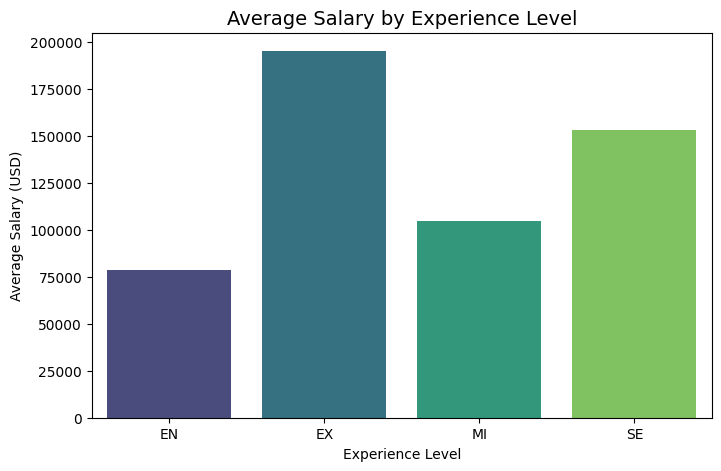

In [5]:
# 3. Create a bar plot showing average salary by experience_level.
avg_salary_exp = df.groupby('experience_level')['salary_in_usd'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=avg_salary_exp, x='experience_level', y='salary_in_usd', palette='viridis')
plt.title('Average Salary by Experience Level', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.show()

<h2>INSIGHTS</h2>
<p>The bar plot shows that the average salary increases with experience level. EN employees earn the lowest average salary, while EX employees have the highest average salary, reaching nearly $200,000. MI and SE employees fall in between, with SE salaries being higher than MI but still below EX. This indicates that higher experience levels generally lead to significantly higher pay.</p>
<hr>

## 🧹 Part 3: Data Preprocessing for Linear Regression

We will predict `salary_in_usd` using **only numerical or encoded categorical features**.

### Steps:
1. Select features: `work_year`, `experience_level`, and optionally `job_title` (you decide!)
2. Encode categorical variables (`experience_level`) using `LabelEncoder` or `pd.get_dummies()`
3. Define `X` (features) and `y` (target = `salary_in_usd`)

> ⚠️ **Important**: Do NOT include `salary`, `salary_currency`, or `salary_in_usd` in your features!

In [6]:
le = LabelEncoder()
df['experience_level_encoded'] = le.fit_transform(df['experience_level'])

features = ['work_year', 'experience_level_encoded']
X = df[features]
y = df['salary_in_usd']

X.head()

,work_year,experience_level_encoded
0,2023,0
1,2023,0
2,2023,0
3,2023,0
4,2023,0


## 📈 Part 4: Train a Linear Regression Model

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # split data into train and test sets

model = LinearRegression() # create 
model.fit(X_train, y_train) # train the model

y_pred = model.predict(X_test) # make predictions

print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.15
RMSE: 59164.82


## 🔮 Part 5: Predict 2024 Salaries

Now, create a small DataFrame for **2024** with different experience levels and predict their salaries.

Use the same encoding as before!

In [8]:
future_data = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'experience_level_encoded': [0, 1, 2, 3]  # EN, MI, SE, EX
})

predicted_salaries = model.predict(future_data) # Predict

results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': predicted_salaries
}) # Display results

results

,Experience Level,Predicted 2024 Salary (USD)
0,Entry,111694.914909
1,Mid,131967.434578
2,Senior,152239.954247
3,Executive,172512.473916


## 📝 Part 6: Reflection (Answer in a Markdown Cell)

1. Does your model make reasonable predictions? Why or why not?
2. What are the limitations of using only `work_year` and `experience_level`?
3. How could you improve this model? (Think: more features, better encoding, etc.)
4. Why is **R² not enough** to trust your predictions?

> 💡 Remember: Linear regression assumes a **linear trend**—but real salaries may grow non-linearly!

<h1>ANSWER:</h1>
<h4>1. Does your model make reasonable predictions? Why or why not?</h4>
<p>Yes, it makes reasonable because higher experience levels get higher predicted salaries. But it’s not very accurate since the R² score is low.</p>

<h4>2. What are the limitations of using only work_year and experience_level?</h4>
<p>It doesn’t include other important factors like job title, company size, or location, which also affect salary.</p>

<h4>3. How could you improve this model? (Think: more features, better encoding, etc.)</h4>
<p>Add more features, use better encoding, or try other models that can handle more complex data.</p>

<h4>4. Why is R² not enough to trust your predictions?</h4>
<p>Because a low R² means the model doesn’t explain much of the salary changes, and salaries don’t always follow a simple linear pattern.</p>
<hr>

## 📤 Submission Instructions

- Save this notebook as: `LastName_FirstName_SalaryPrediction.ipynb`
- Ensure all code runs without errors
- Include your answers to the reflection questions
- Submit via [your LMS/email/etc.]

Good luck! 🚀